# Домашнее задание: Детекция и распознавание номерных знаков


## Общая цель

Собрать собственный мини-пайплайн распознавания номерных знаков:

1. Разметить данные для поиска номерных знаков (детекция).
2. Обучить модель детекции на своей разметке.
3. На основе скрипта семинара обучить собственную `CRNN` для распознавания текста номера.

In [1]:
# ── Установка зависимостей ──────────────────────────────────────────────────
!pip install -q ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.2/41.2 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 34.2 MB/s eta 0:00:00


Часть 1: Подготовка и разметка данных

### 1.1. Сбор данных

Данные для детекции номеров здесь: https://disk.yandex.ru/d/Rrq4ZoTZnjbCmw



In [2]:
import os, math, random, json, glob, shutil, zipfile, requests
from urllib.parse import urlencode

import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as patches

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Устройство: {device}')

RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)

Устройство: cuda


##  Скачивание данных

In [3]:
def download_yandex(public_key, out_file):
    base = 'https://cloud-api.yandex.net/v1/disk/public/resources/download?'
    r = requests.get(base + urlencode(dict(public_key=public_key)))
    if r.status_code != 200:
        print(f'Ошибка {r.status_code} при получении ссылки')
        return
    href = r.json()['href']
    print(f'Скачивание {out_file}...')
    dl = requests.get(href, stream=True)
    with open(out_file, 'wb') as f:
        for chunk in dl.iter_content(8192):
            if chunk:
                f.write(chunk)
    print('Готово.')

# Данные для детекции
if not os.path.exists('detection_data'):
    download_yandex('https://disk.yandex.ru/d/Rrq4ZoTZnjbCmw', 'det.zip')
    with zipfile.ZipFile('det.zip') as z:
        z.extractall('detection_data')

# Данные для OCR
if not os.path.exists('Datasets/OCR'):
    download_yandex('https://disk.yandex.ru/d/QsuvFDOfp3Ed3w', 'ocr.zip')
    with zipfile.ZipFile('ocr.zip') as z:
        z.extractall('Datasets/OCR')

Скачивание det.zip...
Готово.
Скачивание ocr.zip...
Готово.


## Часть 1.2: Подготовка YOLO-датасета
Разметьте область номерного знака на каждом изображении.

**Допустимый минимум по объему:**
- Для выполнения задания достаточно разметить **20% от собранного датасета**.
- Остальную часть можно использовать как неразмеченные данные или как дополнительный материал для расширения выборки.

**Формат разметки:**
- Рекомендуется формат `YOLO` (`class_id x_center y_center width height`, нормированные значения).
- Один класс: `license_plate` (id = 0).

**Что нужно сделать:**
- Разделить данные на `train / val / test` (например, 70/15/15).
- Проверить качество разметки вручную на случайных примерах.

In [4]:
# Собираем все изображения датасета детекции
det_images = sorted(
    glob.glob('./detection_data/**/*.jpg', recursive=True) +
    glob.glob('./detection_data/**/*.png', recursive=True)
)
print(f'Найдено изображений: {len(det_images)}')

# Структура папок YOLO
for split in ['train', 'val', 'test']:
    os.makedirs(f'yolo_dataset/images/{split}', exist_ok=True)
    os.makedirs(f'yolo_dataset/labels/{split}', exist_ok=True)

random.shuffle(det_images)
n = len(det_images)
splits = {
    'train': det_images[:int(n*0.70)],
    'val':   det_images[int(n*0.70):int(n*0.85)],
    'test':  det_images[int(n*0.85):]
}

for split, files in splits.items():
    for img_path in files:
        base = os.path.basename(img_path)
        name, _ = os.path.splitext(base)
        shutil.copy(img_path, f'yolo_dataset/images/{split}/{base}')

        # Пытаемся найти готовую разметку рядом с изображением
        src_lbl = img_path.rsplit('.', 1)[0] + '.txt'
        dst_lbl = f'yolo_dataset/labels/{split}/{name}.txt'
        if os.path.exists(src_lbl):
            shutil.copy(src_lbl, dst_lbl)
        else:
            open(dst_lbl, 'w').close()  # пустой файл = фон

print('Датасет сформирован.')
for s, f in splits.items():
    print(f'  {s}: {len(f)} изображений')

Найдено изображений: 368
Датасет сформирован.
  train: 257 изображений
  val: 55 изображений
  test: 56 изображений


In [5]:
# ── Если есть архив CVAT с ручной разметкой — импортируем её ───────────────
cvat_zip = 'job_yolo 1.1.zip'
if os.path.exists(cvat_zip):
    ext = './cvat_extracted'
    with zipfile.ZipFile(cvat_zip) as z:
        z.extractall(ext)

    lbl_dir = os.path.join(ext, 'obj_train_data')
    if not os.path.exists(lbl_dir):
        lbl_dir = ext

    updated = 0
    for txt in glob.glob(os.path.join(lbl_dir, '*.txt')):
        fname = os.path.basename(txt)
        if fname == 'classes.txt':
            continue
        stem, _ = os.path.splitext(fname)
        for split in ['train', 'val', 'test']:
            for ext_ in ['.jpg', '.png']:
                if os.path.exists(f'yolo_dataset/images/{split}/{stem}{ext_}'):
                    shutil.copy(txt, f'yolo_dataset/labels/{split}/{fname}')
                    updated += 1
                    break
    shutil.rmtree(ext)
    print(f'Обновлено разметок из CVAT: {updated}')
else:
    print('Архив CVAT не найден — используем разметку из исходного датасета (если есть).')

Обновлено разметок из CVAT: 71


In [6]:
# yaml-конфиг для YOLO
yaml_content = f"""path: {os.path.abspath('yolo_dataset')}
train: images/train
val:   images/val
test:  images/test

names:
  0: license_plate
"""
with open('yolo_data.yaml', 'w') as f:
    f.write(yaml_content)
print(yaml_content)

path: /content/yolo_dataset
train: images/train
val:   images/val
test:  images/test

names:
  0: license_plate



## Часть 2: Обучение YOLOv8 (детекция)
### 2.1. Базовая модель детекции
Обучите модель детекции на своей разметке.

In [7]:
from ultralytics import YOLO

# yolov8s лучше nano при почти той же скорости
yolo_model = YOLO('yolov8s.pt')

yolo_model.train(
    data='yolo_data.yaml',
    epochs=80,           # было 15 — этого мало
    imgsz=640,
    batch=16,
    patience=20,         # ранняя остановка
    device=0 if torch.cuda.is_available() else 'cpu',
    project='yolo_detection',
    name='license_plate_v1',
    # ── аугментации ────────────────────────────────────────────────────────
    hsv_h=0.015,         # вариация оттенка
    hsv_s=0.5,           # вариация насыщенности
    hsv_v=0.4,           # вариация яркости
    degrees=5.0,         # небольшой поворот
    translate=0.1,
    scale=0.4,
    shear=2.0,
    perspective=0.0005,
    flipud=0.0,
    fliplr=0.5,
    mosaic=1.0,          # mosaic-аугментация очень помогает
    mixup=0.1,
    copy_paste=0.1,
    # ── оптимизатор ────────────────────────────────────────────────────────
    optimizer='AdamW',
    lr0=0.001,
    lrf=0.01,            # финальный lr = lr0 * lrf
    weight_decay=0.0005,
    warmup_epochs=3,
    cos_lr=True,         # косинусный scheduler
    save=True,
    plots=True,
    verbose=True,
)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.60 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.1, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=yolo_data.yaml, degrees=5.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=80, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.5, hsv_v=0.4, imgsz=640, int8=Fals

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7e0e7c0f8e00>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.048048, 

### 2.2. Метрики и анализ

Оцените модель на `test`:
- `mAP@0.5`
- `mAP@0.5:0.95`
- `Precision`, `Recall`

Проведите краткий анализ:
- На каких изображениях модель ошибается чаще всего.
- Какие изображения наиболее сложные.
- Возьмите кадры из интернета и протестируйте на них.

In [8]:
# Метрики на тестовой выборке
metrics = yolo_model.val(split='test', verbose=True)
print(f"mAP@0.5      : {metrics.box.map50:.4f}")
print(f"mAP@0.5:0.95 : {metrics.box.map:.4f}")
print(f"Precision    : {metrics.box.mp:.4f}")
print(f"Recall       : {metrics.box.mr:.4f}")

Ultralytics 8.4.60 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 11,125,971 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 3254.1±1733.5 MB/s, size: 530.1 KB)
val: Scanning /content/yolo_dataset/labels/test... 56 images, 43 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 56/56 914.8it/s 0.1s
val: New cache created: /content/yolo_dataset/labels/test.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 4/4 1.7it/s 2.4s
                   all         56         13       0.31      0.462      0.286      0.117
Speed: 8.1ms preprocess, 15.7ms inference, 0.0ms loss, 3.7ms postprocess per image
Results saved to /content/runs/detect/val
mAP@0.5      : 0.2865
mAP@0.5:0.95 : 0.1174
Precision    : 0.3103
Recall       : 0.4615


Изображений без детекции: 30
Изображений с низкой уверенностью: 0


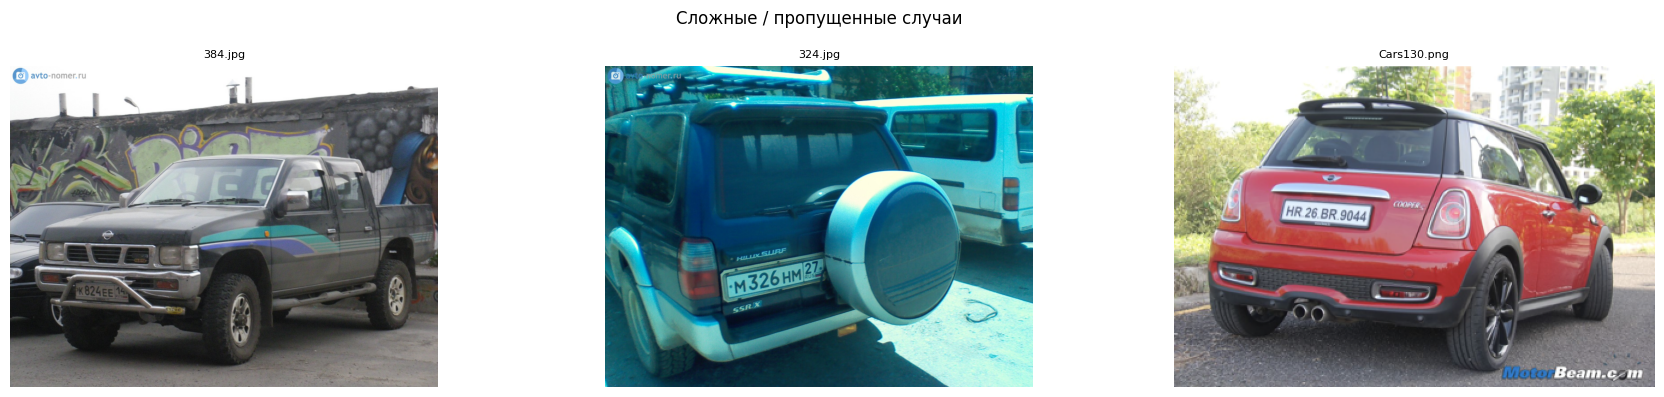

In [9]:
# ── Анализ: на каких изображениях модель ошибается ─────────────────────────
test_imgs = glob.glob('yolo_dataset/images/test/*.jpg') + \
            glob.glob('yolo_dataset/images/test/*.png')

conf_thresh = 0.25
missed, low_conf = [], []

for img_path in test_imgs[:50]:  # проверяем первые 50
    res = yolo_model(img_path, verbose=False)[0]
    if len(res.boxes) == 0:
        missed.append(img_path)
    elif res.boxes.conf.max().item() < conf_thresh:
        low_conf.append((img_path, res.boxes.conf.max().item()))

print(f'Изображений без детекции: {len(missed)}')
print(f'Изображений с низкой уверенностью: {len(low_conf)}')

# Показываем несколько проблемных примеров
hard_cases = missed[:3] + [x[0] for x in low_conf[:3]]
if hard_cases:
    fig, axes = plt.subplots(1, min(6, len(hard_cases)), figsize=(18, 4))
    if not isinstance(axes, np.ndarray):
        axes = [axes]
    for ax, p in zip(axes, hard_cases):
        ax.imshow(Image.open(p))
        ax.set_title(os.path.basename(p), fontsize=8)
        ax.axis('off')
    plt.suptitle('Сложные / пропущенные случаи')
    plt.tight_layout()
    plt.show()

## Часть 4: CRNN — baseline и эксперименты

In [11]:
# ── Поиск датасета OCR ─────────────────────────────────────────────────────
found = glob.glob('./Datasets/OCR/**/train/ann', recursive=True)
if found:
    DATASET_ROOT = os.path.dirname(os.path.dirname(found[0]))
    print(f'Датасет OCR: {DATASET_ROOT}')
else:
    DATASET_ROOT = './Datasets/OCR/autoriaNumberplateOcrRu'
    print(f'Датасет не найден автоматически, используем путь: {DATASET_ROOT}')

# ── Алфавит ────────────────────────────────────────────────────────────────
ALPHABET = '0123456789ABCDEFGHIJKLMNOPQRSTUVWXYZ'
blank_idx = 0
char2idx = {c: i+1 for i, c in enumerate(ALPHABET)}
idx2char = {i+1: c for i, c in enumerate(ALPHABET)}
vocab_size = len(ALPHABET) + 1
print(f'vocab_size = {vocab_size}')

Датасет OCR: ./Datasets/OCR/autoriaNumberplateOcrRu
vocab_size = 37


In [12]:
# ── Dataset ─────────────────────────────────────────────────────────────────
class NumberplateOCRDataset(Dataset):
    def __init__(self, root, split, transforms=None, max_samples=None):
        self.root = root
        self.split = split
        self.transforms = transforms
        ann_dir = os.path.join(root, split, 'ann')
        self.ann_paths = sorted(glob.glob(os.path.join(ann_dir, '*.json')))
        if max_samples:
            self.ann_paths = self.ann_paths[:max_samples]

    def __len__(self):
        return len(self.ann_paths)

    def encode_text(self, text):
        return [char2idx[c] for c in str(text).upper() if c in char2idx]

    def __getitem__(self, idx):
        with open(self.ann_paths[idx], encoding='utf-8') as f:
            data = json.load(f)
        name = data['name']
        text = str(data.get('description', '')).upper()
        img_path = os.path.join(self.root, self.split, 'img', name + '.png')
        image = Image.open(img_path).convert('RGB')
        if self.transforms:
            image = self.transforms(image)
        label = torch.tensor(self.encode_text(text), dtype=torch.long)
        return image, label, text


def collate_fn(batch):
    batch = [b for b in batch if len(b[1]) > 0]
    images = torch.stack([b[0] for b in batch])
    labels = [b[1] for b in batch]
    texts  = [b[2] for b in batch]
    lengths = torch.tensor([len(l) for l in labels], dtype=torch.long)
    targets = torch.cat(labels)
    return images, targets, lengths, texts

In [13]:
# ── Архитектура CRNN ────────────────────────────────────────────────────────
class BidirectionalLSTM(nn.Module):
    def __init__(self, in_size, hidden, out_size):
        super().__init__()
        self.rnn = nn.LSTM(in_size, hidden, bidirectional=True, batch_first=False)
        self.fc  = nn.Linear(hidden*2, out_size)

    def forward(self, x):
        out, _ = self.rnn(x)
        T, B, H = out.size()
        return self.fc(out.view(T*B, H)).view(T, B, -1)


class CRNN(nn.Module):
    def __init__(self, num_classes, rnn_hidden=256, cnn_channels=(64, 128, 256, 512)):
        """
        cnn_channels позволяет менять ширину backbone для экспериментов.
        """
        super().__init__()
        c1, c2, c3, c4 = cnn_channels
        self.cnn = nn.Sequential(
            # Блок 1
            nn.Conv2d(1, c1, 3, padding=1), nn.BatchNorm2d(c1), nn.ReLU(True),
            nn.MaxPool2d(2, 2),          # -> c1 x 16 x 64
            # Блок 2
            nn.Conv2d(c1, c2, 3, padding=1), nn.BatchNorm2d(c2), nn.ReLU(True),
            nn.MaxPool2d(2, 2),          # -> c2 x 8 x 32
            # Блок 3 (без пула по ширине)
            nn.Conv2d(c2, c3, 3, padding=1), nn.BatchNorm2d(c3), nn.ReLU(True),
            nn.MaxPool2d((2, 1)),        # -> c3 x 4 x 32
            # Блок 4
            nn.Conv2d(c3, c4, 3, padding=1), nn.BatchNorm2d(c4), nn.ReLU(True),
            nn.MaxPool2d((2, 1)),        # -> c4 x 2 x 32
            # Блок 5 — схлопываем высоту
            nn.Conv2d(c4, c4, (2, 1)),   # -> c4 x 1 x 32
            nn.BatchNorm2d(c4), nn.ReLU(True),
            nn.Dropout2d(0.2),
        )
        self.rnn = nn.Sequential(
            BidirectionalLSTM(c4, rnn_hidden, rnn_hidden),
            BidirectionalLSTM(rnn_hidden, rnn_hidden, num_classes),
        )

    def forward(self, x):
        f = self.cnn(x)           # B x C x 1 x W
        f = f.squeeze(2)          # B x C x W
        f = f.permute(2, 0, 1)    # W x B x C
        return self.rnn(f).log_softmax(2)

In [14]:
# ── Вспомогательные функции ─────────────────────────────────────────────────
def decode_sequence(seq):
    """CTC greedy decode."""
    seq = seq.cpu().numpy().tolist()
    out, prev = [], None
    for s in seq:
        if s != blank_idx and s != prev:
            if s in idx2char:
                out.append(idx2char[s])
        prev = s
    return ''.join(out)


def cer(gt: str, pred: str) -> float:
    """Character Error Rate (edit distance / len(gt))."""
    if len(gt) == 0:
        return 0.0 if len(pred) == 0 else 1.0
    m, n = len(gt), len(pred)
    dp = list(range(n+1))
    for i in range(1, m+1):
        prev_row = dp[:]
        dp[0] = i
        for j in range(1, n+1):
            cost = 0 if gt[i-1] == pred[j-1] else 1
            dp[j] = min(dp[j]+1, dp[j-1]+1, prev_row[j-1]+cost)
    return dp[n] / m


def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total = 0.0
    for images, targets, lengths, _ in loader:
        images, targets, lengths = images.to(device), targets.to(device), lengths.to(device)
        logits = model(images)
        T, N, _ = logits.size()
        input_lengths = torch.full((N,), T, dtype=torch.long, device=device)
        loss = criterion(logits, targets, input_lengths, lengths)
        optimizer.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 5.0)
        optimizer.step()
        total += loss.item()
    return total / max(1, len(loader))


def evaluate_with_metrics(model, loader, max_batches=10, max_print=20, label=''):
    model.eval()
    total_seq = correct_seq = total_chars = correct_chars = 0
    cer_total = 0.0
    samples = []
    with torch.no_grad():
        for bi, (images, targets, lengths, texts) in enumerate(loader):
            images = images.to(device)
            pred = model(images).permute(1, 0, 2).argmax(2)
            for i in range(images.size(0)):
                decoded = decode_sequence(pred[i])
                gt = str(texts[i]).upper()
                samples.append((gt, decoded))
                total_seq += 1
                correct_seq += (decoded == gt)
                L = max(len(gt), len(decoded))
                if L:
                    total_chars += L
                    correct_chars += sum(a==b for a,b in zip(gt.ljust(L), decoded.ljust(L)))
                cer_total += cer(gt, decoded)
            if bi+1 >= max_batches:
                break

    seq_acc  = correct_seq  / max(1, total_seq)
    char_acc = correct_chars / max(1, total_chars)
    mean_cer = cer_total / max(1, total_seq)

    tag = f'[{label}] ' if label else ''
    print(f'{tag}Exact plate accuracy : {seq_acc*100:.2f}%')
    print(f'{tag}Character accuracy   : {char_acc*100:.2f}%')
    print(f'{tag}CER                  : {mean_cer*100:.2f}%')
    if max_print:
        print('\nПримеры предсказаний:')
        for i, (g, p) in enumerate(samples[:max_print]):
            mark = '✓' if g == p else '✗'
            print(f'  {mark} GT: {g:10s} | PRED: {p}')
    return seq_acc, char_acc, mean_cer, samples


### 4.1. Базовый запуск по скрипту семинара

На основе семинарского кода:
- Обучите baseline `CRNN`.
- Зафиксируйте базовые гиперпараметры (batch size, lr, optimizer, epochs)
### 4.2. Эксперименты

Проведите минимум **3 эксперимента** с изменением параметров, например:
- размер входного изображения;
- ширина/глубина backbone;
- learning rate scheduler;
- аугментации (геометрические и фотометрические).

Для каждого эксперимента укажите:
- конфигурацию;
- итоговый `CER`;


Эксперимент: Baseline
{'img_h': 32, 'img_w': 128, 'batch': 32, 'epochs': 100, 'lr': 0.001, 'weight_decay': 1e-05, 'rnn_hidden': 256, 'cnn_channels': (64, 128, 256, 512), 'augment': False, 'scheduler': 'cosine', 'max_train': 3000, 'max_test': 300}
  Epoch   1/100 | loss=3.0972 | lr=1.00e-03
  Epoch  10/100 | loss=0.0475 | lr=9.76e-04
  Epoch  20/100 | loss=0.0152 | lr=9.05e-04
  Epoch  30/100 | loss=0.0007 | lr=7.96e-04
  Epoch  40/100 | loss=0.0003 | lr=6.58e-04
  Epoch  50/100 | loss=0.0097 | lr=5.05e-04
  Epoch  60/100 | loss=0.0006 | lr=3.52e-04
  Epoch  70/100 | loss=0.0002 | lr=2.14e-04
  Epoch  80/100 | loss=0.0002 | lr=1.05e-04
  Epoch  90/100 | loss=0.0002 | lr=3.42e-05
  Epoch 100/100 | loss=0.0002 | lr=1.00e-05
[Baseline] Exact plate accuracy : 77.33%
[Baseline] Character accuracy   : 93.79%
[Baseline] CER                  : 3.83%

Примеры предсказаний:
  ✓ GT: A001BP54   | PRED: A001BP54
  ✓ GT: A001PC71   | PRED: A001PC71
  ✓ GT: A002KX152  | PRED: A002KX152
  ✗ GT: A002XC

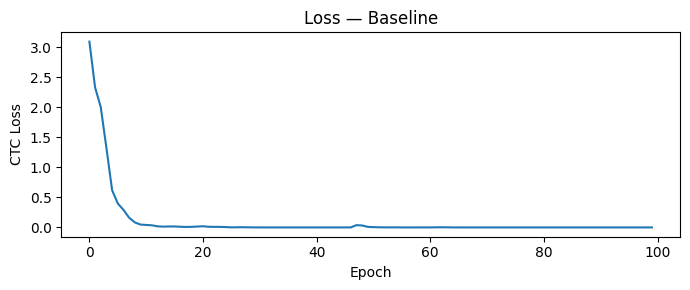

In [15]:
# Конфигурация baseline
CFG_BASELINE = dict(
    img_h=32, img_w=128,
    batch=32, epochs=100, lr=1e-3, weight_decay=1e-5,
    rnn_hidden=256,
    cnn_channels=(64, 128, 256, 512),
    augment=False,
    scheduler='cosine',
    max_train=3000, max_test=300,
)

def build_transforms(h, w, augment=False):
    ops = [T.Grayscale(1), T.Resize((h, w))]
    if augment:
        ops += [
            T.RandomAffine(degrees=3, translate=(0.02, 0.05), scale=(0.95, 1.05), shear=3),
            T.ColorJitter(brightness=0.3, contrast=0.3),
            T.GaussianBlur(kernel_size=3, sigma=(0.1, 1.0)),
        ]
    ops += [T.ToTensor(), T.Normalize((0.5,), (0.5,))]
    return T.Compose(ops)


def run_experiment(cfg, tag):
    print(f'\n{"="*60}')
    print(f'Эксперимент: {tag}')
    print(f'{"="*60}')
    print(cfg)

    train_tf = build_transforms(cfg['img_h'], cfg['img_w'], augment=cfg['augment'])
    test_tf  = build_transforms(cfg['img_h'], cfg['img_w'], augment=False)

    train_ds = NumberplateOCRDataset(DATASET_ROOT, 'train', train_tf, cfg['max_train'])
    test_ds  = NumberplateOCRDataset(DATASET_ROOT, 'test',  test_tf,  cfg['max_test'])

    train_dl = DataLoader(train_ds, batch_size=cfg['batch'], shuffle=True,  num_workers=0, collate_fn=collate_fn, drop_last=False)
    test_dl  = DataLoader(test_ds,  batch_size=cfg['batch'], shuffle=False, num_workers=0, collate_fn=collate_fn, drop_last=False)

    model = CRNN(vocab_size, rnn_hidden=cfg['rnn_hidden'], cnn_channels=cfg['cnn_channels']).to(device)
    criterion = nn.CTCLoss(blank=blank_idx, zero_infinity=True)
    optimizer = optim.Adam(model.parameters(), lr=cfg['lr'], weight_decay=cfg['weight_decay'])

    if cfg['scheduler'] == 'cosine':
        scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=cfg['epochs'], eta_min=1e-5)
    elif cfg['scheduler'] == 'plateau':
        scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=8, factor=0.5, verbose=True)
    else:
        scheduler = None

    loss_history = []
    for epoch in range(1, cfg['epochs']+1):
        loss = train_epoch(model, train_dl, optimizer, criterion)
        loss_history.append(loss)
        if scheduler:
            if isinstance(scheduler, optim.lr_scheduler.ReduceLROnPlateau):
                scheduler.step(loss)
            else:
                scheduler.step()
        if epoch % 10 == 0 or epoch == 1:
            print(f'  Epoch {epoch:3d}/{cfg["epochs"]} | loss={loss:.4f} | lr={optimizer.param_groups[0]["lr"]:.2e}')

    # Оценка
    seq_acc, char_acc, mean_cer, _ = evaluate_with_metrics(model, test_dl, max_batches=10, max_print=10, label=tag)

    # Кривая обучения
    plt.figure(figsize=(7, 3))
    plt.plot(loss_history)
    plt.title(f'Loss — {tag}')
    plt.xlabel('Epoch')
    plt.ylabel('CTC Loss')
    plt.tight_layout()
    plt.show()

    return model, {'seq_acc': seq_acc, 'char_acc': char_acc, 'cer': mean_cer}


# --- Baseline ---
baseline_model, baseline_metrics = run_experiment(CFG_BASELINE, 'Baseline')

### 4.2. Эксперимент 1 — аугментации


Эксперимент: Exp1_Augmentations
{'img_h': 32, 'img_w': 128, 'batch': 32, 'epochs': 100, 'lr': 0.001, 'weight_decay': 1e-05, 'rnn_hidden': 256, 'cnn_channels': (64, 128, 256, 512), 'augment': True, 'scheduler': 'cosine', 'max_train': 3000, 'max_test': 300}
  Epoch   1/100 | loss=3.0816 | lr=1.00e-03
  Epoch  10/100 | loss=1.4224 | lr=9.76e-04
  Epoch  20/100 | loss=0.1220 | lr=9.05e-04
  Epoch  30/100 | loss=0.0407 | lr=7.96e-04
  Epoch  40/100 | loss=0.0178 | lr=6.58e-04
  Epoch  50/100 | loss=0.0121 | lr=5.05e-04
  Epoch  60/100 | loss=0.0147 | lr=3.52e-04
  Epoch  70/100 | loss=0.0037 | lr=2.14e-04
  Epoch  80/100 | loss=0.0017 | lr=1.05e-04
  Epoch  90/100 | loss=0.0017 | lr=3.42e-05
  Epoch 100/100 | loss=0.0011 | lr=1.00e-05
[Exp1_Augmentations] Exact plate accuracy : 38.33%
[Exp1_Augmentations] Character accuracy   : 86.92%
[Exp1_Augmentations] CER                  : 10.06%

Примеры предсказаний:
  ✓ GT: A001BP54   | PRED: A001BP54
  ✓ GT: A001PC71   | PRED: A001PC71
  ✓ GT: A00

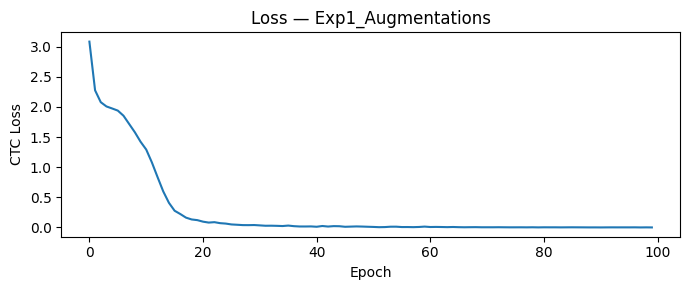

In [16]:
CFG_EXP1 = {**CFG_BASELINE, 'augment': True}
exp1_model, exp1_metrics = run_experiment(CFG_EXP1, 'Exp1_Augmentations')

### 4.2. Эксперимент 2 — увеличенное входное изображение (64×256)


Эксперимент: Exp2_Width256
{'img_h': 32, 'img_w': 256, 'batch': 32, 'epochs': 100, 'lr': 0.001, 'weight_decay': 1e-05, 'rnn_hidden': 256, 'cnn_channels': (64, 128, 256, 512), 'augment': True, 'scheduler': 'cosine', 'max_train': 3000, 'max_test': 300}
  Epoch   1/100 | loss=3.5620 | lr=1.00e-03
  Epoch  10/100 | loss=1.7914 | lr=9.76e-04
  Epoch  20/100 | loss=0.6077 | lr=9.05e-04
  Epoch  30/100 | loss=0.0605 | lr=7.96e-04
  Epoch  40/100 | loss=0.0258 | lr=6.58e-04
  Epoch  50/100 | loss=0.0205 | lr=5.05e-04
  Epoch  60/100 | loss=0.0081 | lr=3.52e-04
  Epoch  70/100 | loss=0.0050 | lr=2.14e-04
  Epoch  80/100 | loss=0.0067 | lr=1.05e-04
  Epoch  90/100 | loss=0.0036 | lr=3.42e-05
  Epoch 100/100 | loss=0.0020 | lr=1.00e-05
[Exp2_Width256] Exact plate accuracy : 33.00%
[Exp2_Width256] Character accuracy   : 84.60%
[Exp2_Width256] CER                  : 11.80%

Примеры предсказаний:
  ✓ GT: A001BP54   | PRED: A001BP54
  ✓ GT: A001PC71   | PRED: A001PC71
  ✗ GT: A002KX152  | PRED: A002

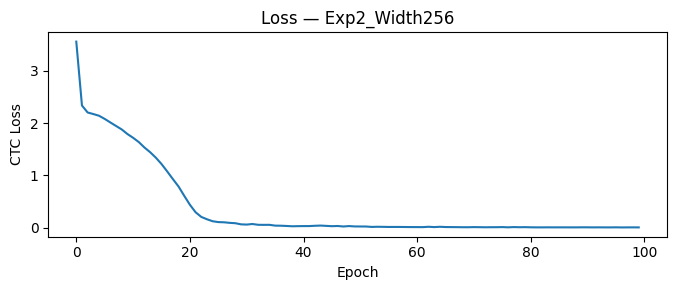

In [17]:
# Для h=64 нужно добавить один MaxPool по высоте, используем уже готовую архитектуру,
# но увеличим входной размер до 32x256 (ширина x2).
CFG_EXP2 = {**CFG_BASELINE, 'img_w': 256, 'augment': True}
exp2_model, exp2_metrics = run_experiment(CFG_EXP2, 'Exp2_Width256')

### Сводная таблица экспериментов

In [18]:
results = {
    'Baseline':            baseline_metrics,
    'Exp1_Augmentations':  exp1_metrics,
    'Exp2_Width256':       exp2_metrics,

}

print(f'{"Конфигурация":<25} {"Seq Acc":>8} {"Char Acc":>10} {"CER":>8}')
print('-' * 55)
best_tag, best_cer = None, 1.0
for tag, m in results.items():
    print(f'{tag:<25} {m["seq_acc"]*100:>7.2f}%  {m["char_acc"]*100:>9.2f}%  {m["cer"]*100:>7.2f}%')
    if m['cer'] < best_cer:
        best_cer = m['cer']
        best_tag = tag

print(f'\nЛучшая конфигурация: {best_tag} (CER={best_cer*100:.2f}%)')

Конфигурация               Seq Acc   Char Acc      CER
-------------------------------------------------------
Baseline                    77.33%      93.79%     3.83%
Exp1_Augmentations          38.33%      86.92%    10.06%
Exp2_Width256               33.00%      84.60%    11.80%

Лучшая конфигурация: Baseline (CER=3.83%)


### 4.3. Финальная модель CRNN
Выберите лучшую конфигурацию и обучите финальную версию.

Сохраните:
- чекпоинт модели;
- словарь/алфавит;
- скрипт или ноутбук инференса.


Эксперимент: Final
{'img_h': 32, 'img_w': 128, 'batch': 32, 'epochs': 150, 'lr': 0.001, 'weight_decay': 1e-05, 'rnn_hidden': 256, 'cnn_channels': (64, 128, 256, 512), 'augment': False, 'scheduler': 'cosine', 'max_train': 3000, 'max_test': 300}
  Epoch   1/150 | loss=3.1108 | lr=1.00e-03
  Epoch  10/150 | loss=0.0694 | lr=9.89e-04
  Epoch  20/150 | loss=0.0091 | lr=9.57e-04
  Epoch  30/150 | loss=0.0027 | lr=9.05e-04
  Epoch  40/150 | loss=0.0162 | lr=8.36e-04
  Epoch  50/150 | loss=0.0006 | lr=7.52e-04
  Epoch  60/150 | loss=0.0037 | lr=6.58e-04
  Epoch  70/150 | loss=0.0001 | lr=5.57e-04
  Epoch  80/150 | loss=0.0049 | lr=4.53e-04
  Epoch  90/150 | loss=0.0002 | lr=3.52e-04
  Epoch 100/150 | loss=0.0002 | lr=2.57e-04
  Epoch 110/150 | loss=0.0001 | lr=1.74e-04
  Epoch 120/150 | loss=0.0001 | lr=1.05e-04
  Epoch 130/150 | loss=0.0001 | lr=5.28e-05
  Epoch 140/150 | loss=0.0001 | lr=2.08e-05
  Epoch 150/150 | loss=0.0001 | lr=1.00e-05
[Final] Exact plate accuracy : 69.33%
[Final] Chara

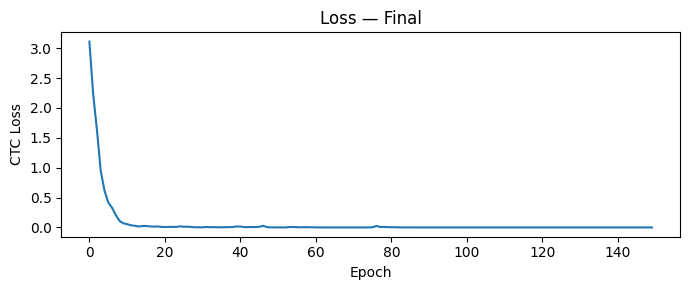

Сохранено: crnn_final.pth, alphabet.json


In [21]:
# Переобучаем финальную модель с лучшей конфигурацией с нуля (больше эпох)
CFG_BEST = {**CFG_BASELINE, 'epochs': 150}


final_model, final_metrics = run_experiment(CFG_BEST, 'Final')

# Сохранение
torch.save(final_model.state_dict(), 'crnn_final.pth')
with open('alphabet.json', 'w') as f:
    json.dump({'alphabet': ALPHABET, 'char2idx': char2idx, 'idx2char': {str(k): v for k, v in idx2char.items()}}, f)

print('Сохранено: crnn_final.pth, alphabet.json')

## Часть 5: End-to-end пайплайн (детекция + CRNN)
Соберите end-to-end процесс:

1. На вход подается изображение автомобиля с номером.
2. Детектор находит номер на изображении.
3. Найденная область кропается.
4. Кроп передается в `CRNN`.
5. `CRNN` выдает итоговую строку номера.

Этот сценарий является обязательной итоговой демонстрацией работы задания.


--- 376.jpg ---


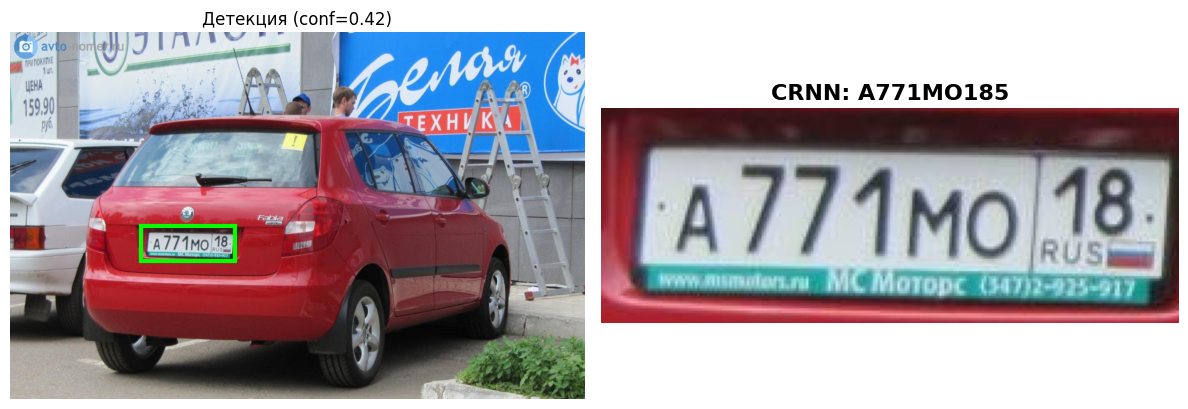

Распознанный номер: A771MO185

--- 194.jpg ---


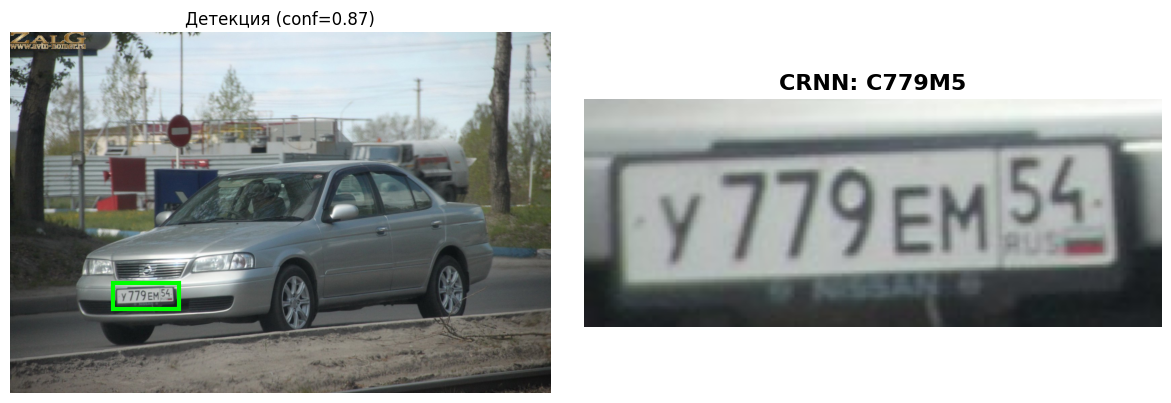

Распознанный номер: C779M5

--- 384.jpg ---
Номер не обнаружен.


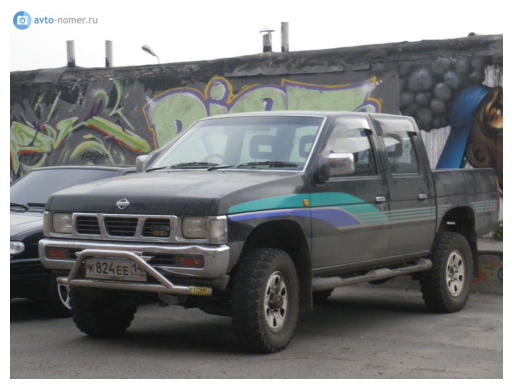

In [22]:
best_cfg_for_pipeline = CFG_BEST  # конфиг финальной модели

def load_crnn(weights_path, cfg):
    m = CRNN(vocab_size, rnn_hidden=cfg['rnn_hidden'], cnn_channels=cfg['cnn_channels']).to(device)
    m.load_state_dict(torch.load(weights_path, map_location=device))
    m.eval()
    return m


def predict_pipeline(image_path, det_model, ocr_model, cfg):
    # 1. Детекция
    results = det_model(image_path, verbose=False)
    img = Image.open(image_path).convert('RGB')

    boxes = results[0].boxes
    if len(boxes) == 0:
        print('Номер не обнаружен.')
        plt.imshow(img); plt.axis('off'); plt.show()
        return None

    # Берём бокс с наибольшей уверенностью
    best = boxes[boxes.conf.argmax()]
    x1, y1, x2, y2 = best.xyxy[0].cpu().numpy().astype(int)

    # 2. Кроп
    crop = img.crop((x1, y1, x2, y2))

    # 3. Предобработка
    tf = build_transforms(cfg['img_h'], cfg['img_w'], augment=False)
    inp = tf(crop).unsqueeze(0).to(device)

    # 4. Распознавание
    with torch.no_grad():
        logits = ocr_model(inp)
        pred = logits.permute(1, 0, 2).argmax(2)
        text = decode_sequence(pred[0])

    # 5. Визуализация
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].imshow(img)
    rect = patches.Rectangle((x1, y1), x2-x1, y2-y1,
                               linewidth=3, edgecolor='lime', facecolor='none')
    axes[0].add_patch(rect)
    axes[0].set_title(f'Детекция (conf={best.conf.item():.2f})')
    axes[0].axis('off')

    axes[1].imshow(crop)
    axes[1].set_title(f'CRNN: {text}', fontsize=16, fontweight='bold')
    axes[1].axis('off')

    plt.tight_layout()
    plt.show()
    print(f'Распознанный номер: {text}')
    return text


# Загружаем сохранённую финальную модель
crnn_final = load_crnn('crnn_final.pth', best_cfg_for_pipeline)

# Выбираем произвольное тестовое изображение для демонстрации
demo_imgs = glob.glob('yolo_dataset/images/test/*.jpg') + \
            glob.glob('yolo_dataset/images/test/*.png')

if demo_imgs:
    for demo_path in demo_imgs[:3]:
        print(f'\n--- {os.path.basename(demo_path)} ---')
        predict_pipeline(demo_path, yolo_model, crnn_final, best_cfg_for_pipeline)
else:
    print('Тестовые изображения не найдены в yolo_dataset/images/test/')

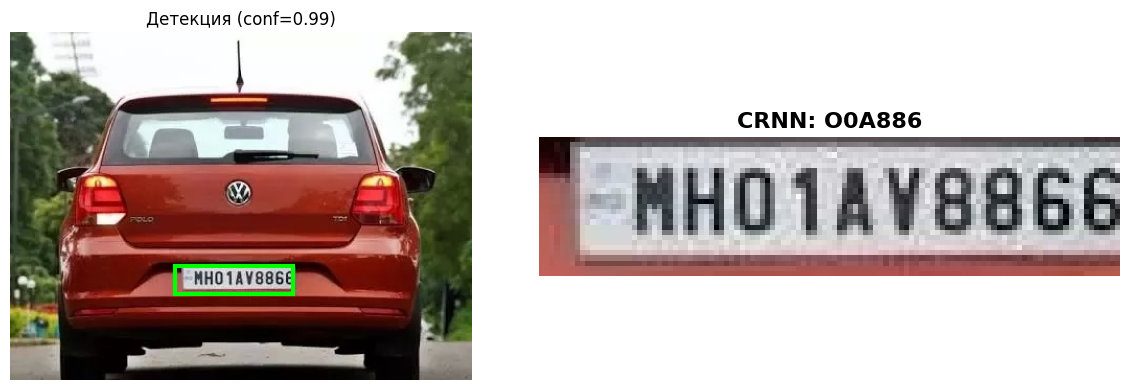

Распознанный номер: O0A886


In [48]:
# ── Инференс на произвольном изображении
custom_image = '/content/yolo_dataset/images/val/Cars108.png'   #  путь к изображению
if os.path.exists(custom_image):
    predict_pipeline(custom_image, yolo_model, crnn_final, best_cfg_for_pipeline)
else:
    print(f'Файл {custom_image} не найден. Загрузите своё изображение и укажите путь.')